## <span style="color: #C7CCD4; font-size: 28px; font-weight: bold;">Importing Modules</span>

In [139]:
import pandas as pd 
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt 

from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE


from sklearn.linear_model import LogisticRegression  
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier,AdaBoostClassifier
from xgboost import XGBClassifier


from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import (GridSearchCV,train_test_split)
from imblearn.pipeline import Pipeline as ImbPipeline


from sklearn.metrics import (accuracy_score, recall_score, roc_auc_score,log_loss
                              ,precision_score, f1_score, roc_curve,precision_recall_curve,
                                average_precision_score,)

from sklearn.base import clone
import shap
import time
import warnings
warnings.filterwarnings('ignore')

## <span style="color: #FF1778; font-size: 28px; font-weight: bold;">Feature Extraction</span>

In [2]:
df=pd.read_csv('Final.csv')

In [102]:
df.head()

,Res_Age,State,Edu_level,Water_Source_Time,Toilet_Facility,House_electricity,House_radio,House_tv,House_bicycle,House_motorcycle,...,Religion_Sikh,Ethnicity_No caste / tribe,Ethnicity_Tribe,ResidenceType_Urban,Water_Source_Natural Source,Water_Source_Other,Water_Source_Piped,DPT_full,MEASLES_full,JE_full
0,38,Jammu & Kashmir,2,0,1,1,1,1,0,0,...,0,0,0,0,0,0,1,0,0,0
1,39,Jammu & Kashmir,1,0,1,1,1,0,1,0,...,0,0,0,0,0,0,1,1,1,0
2,30,Jammu & Kashmir,2,0,1,1,0,1,1,0,...,0,0,0,0,0,0,1,1,1,0
3,32,Jammu & Kashmir,2,0,1,1,1,1,1,0,...,0,0,0,0,0,0,1,0,0,0
4,29,Jammu & Kashmir,2,0,1,1,1,1,1,0,...,0,0,0,0,0,0,1,0,0,0


In [128]:
df.columns

Index(['Res_Age', 'State', 'Edu_level', 'Water_Source_Time', 'Toilet_Facility',
       'House_electricity', 'House_radio', 'House_tv', 'House_bicycle',
       'House_motorcycle', 'House_car', 'Household_members', 'Child_under5',
       'House_telephone', 'Wealth_Idx_Lb', 'Tot_child_born', 'Sons_died',
       'Daughters_died', 'Curr_Preg', 'LastChild_Want', 'Curr_BrstFeed',
       'ChildFood_bottle', 'Child_putToBrst', 'Resp_weight', 'Resp_height',
       'Hg_levelAdjusted', 'Anemia_level', 'HealthInsurance', 'B_ChildTwin',
       'ChildAlive', 'Tetanus_BBirth', 'Antenatal_visits', 'Delivery_CSection',
       'Birth_Size', 'Birth_Weight', 'Child_Brst', 'Preg_Complication',
       'Preg_iron', 'ChildGiven_otherBMilk', 'First3Day_water',
       'First3Day_glucose', 'First3Day_gripeWater', 'First3Day_saltSol',
       'First3Day_fruitJuice', 'First3Day_infFormu', 'First3Day_tea',
       'First3Day_honey', 'First3Day_janamGhutti', 'First3Day_other',
       'Preg_intParaDrug', 'HepatitisB_atB

In [5]:
df.shape

(136136, 95)

In [6]:
df.size

12932920

In [7]:
df['Diabetes'].value_counts()

Diabetes
0    134909
1      1227
Name: count, dtype: int64

In [143]:
print(f"Prevalence of Diabetes:{round(df['Diabetes'].mean()*100 ,2)}%")

Prevalence of Diabetes:0.9%


In [152]:

# ── Target ───────────────────────────────────────────────────────────────
TARGET = "Diabetes"

# ── Columns to KEEP: directly relevant to the woman's own diabetes risk ───
demographic = ["Res_Age", "Married_age", "ResidenceType_Urban",
               "Religion_Muslim", "Religion_Other", "Religion_Sikh",
               "Ethnicity_No caste / tribe", "Ethnicity_Tribe"]

socioeconomic = ["Edu_level", "Wealth_Idx_Lb", "HealthInsurance"]

measurement = ["Resp_weight", "Resp_height"]   # → used to derive BMI next step

lifestyle = ["Smoke", "Smoke_atHome", "Tobacco", "Betel_Leaf", "Alcohol"]

issue = ["Hypertension"]   # established metabolic-syndrome co-risk factor

KEEP_COLS = demographic + socioeconomic + measurement + lifestyle + issue
STRATIFY_COL = "State"           # not a model feature — used for the train/test split

# ── Columns to DROP and why ────────────────────────────────────────────────
# 1. Child / pregnancy / delivery / vaccination specific — irrelevant to HER
#    diabetes status, and only populated for women with a recent birth:
drop_child_maternal = [
    "Child_under5","Sons_died","Daughters_died","Curr_Preg","LastChild_Want",
    "Curr_BrstFeed","ChildFood_bottle","Child_putToBrst","B_ChildTwin",
    "ChildAlive","Tetanus_BBirth","Antenatal_visits","Delivery_CSection",
    "Birth_Size","Birth_Weight","Child_Brst","Preg_Complication","Preg_iron",
    "ChildGiven_otherBMilk","First3Day_water","First3Day_glucose",
    "First3Day_gripeWater","First3Day_saltSol","First3Day_fruitJuice",
    "First3Day_infFormu","First3Day_tea","First3Day_honey",
    "First3Day_janamGhutti","First3Day_other","Preg_intParaDrug",
    "HepatitisB_atBirth","ShortBreaths","VitaminA","IronPill",
    "IntestinalDrug","ChildAge_mnths","Hg_child_adjust","PostnatalChk",
    "DPTB","MMR","DeliveryPlace_Other","DeliveryPlace_Private",
    "B_ChildSex_Male","DPT_full","MEASLES_full","JE_full",
    "Tot_child_born","ultrasound","Prenatal_care","Resp_healthChk",
]

# 2. Redundant with Wealth_Idx_Lb — the wealth index is ALREADY a composite
#    built from these asset variables, so including both double-counts them:
drop_redundant_assets = [
    "House_electricity","House_radio","House_tv","House_bicycle",
    "House_motorcycle","House_car","House_telephone","Household_members",
    "Toilet_Facility","Water_Source_Time","Water_Source_Natural Source",
    "Water_Source_Other","Water_Source_Piped",
]

# 3. Comorbidities you should be CAUTIOUS about, not blindly drop OR keep —
#    these can be *consequences* of diabetes (reverse causation / leakage),
#    not risk factors for it. Leaving them out for now; revisit if you want
#    a "comorbidity profile" angle instead of a clean risk-prediction model:
drop_possible_leakage = ["HeartDisease","Kidney","Thyroid","Cancer","RespDisease"]

# 4. Low relevance / unclear coding, dropped for a first clean pass:
drop_other = ["Related","Benefit_HCare","Curr_MaritalStatus_Single Parent",
              "Anemia_level","Hg_levelAdjusted"]  # ← these last two are the
              # anemia biomarkers from our earlier discussion; excluded here
              # since you chose Diabetes as target, not anemia.

dfc = df[[TARGET, STRATIFY_COL] + KEEP_COLS].copy()
dfc_copy=dfc
print(f"Original shape : {df.shape}")
print(f"Model-ready shape: {dfc.shape}")
print(f"\nColumns kept ({len(KEEP_COLS)}):")
for c in KEEP_COLS:
    print(" -", c)

Original shape : (136136, 95)
Model-ready shape: (136136, 21)

Columns kept (19):
 - Res_Age
 - Married_age
 - ResidenceType_Urban
 - Religion_Muslim
 - Religion_Other
 - Religion_Sikh
 - Ethnicity_No caste / tribe
 - Ethnicity_Tribe
 - Edu_level
 - Wealth_Idx_Lb
 - HealthInsurance
 - Resp_weight
 - Resp_height
 - Smoke
 - Smoke_atHome
 - Tobacco
 - Betel_Leaf
 - Alcohol
 - Hypertension


In [153]:
dfc.size

2858856

Saved: figures/Initial_corr.png


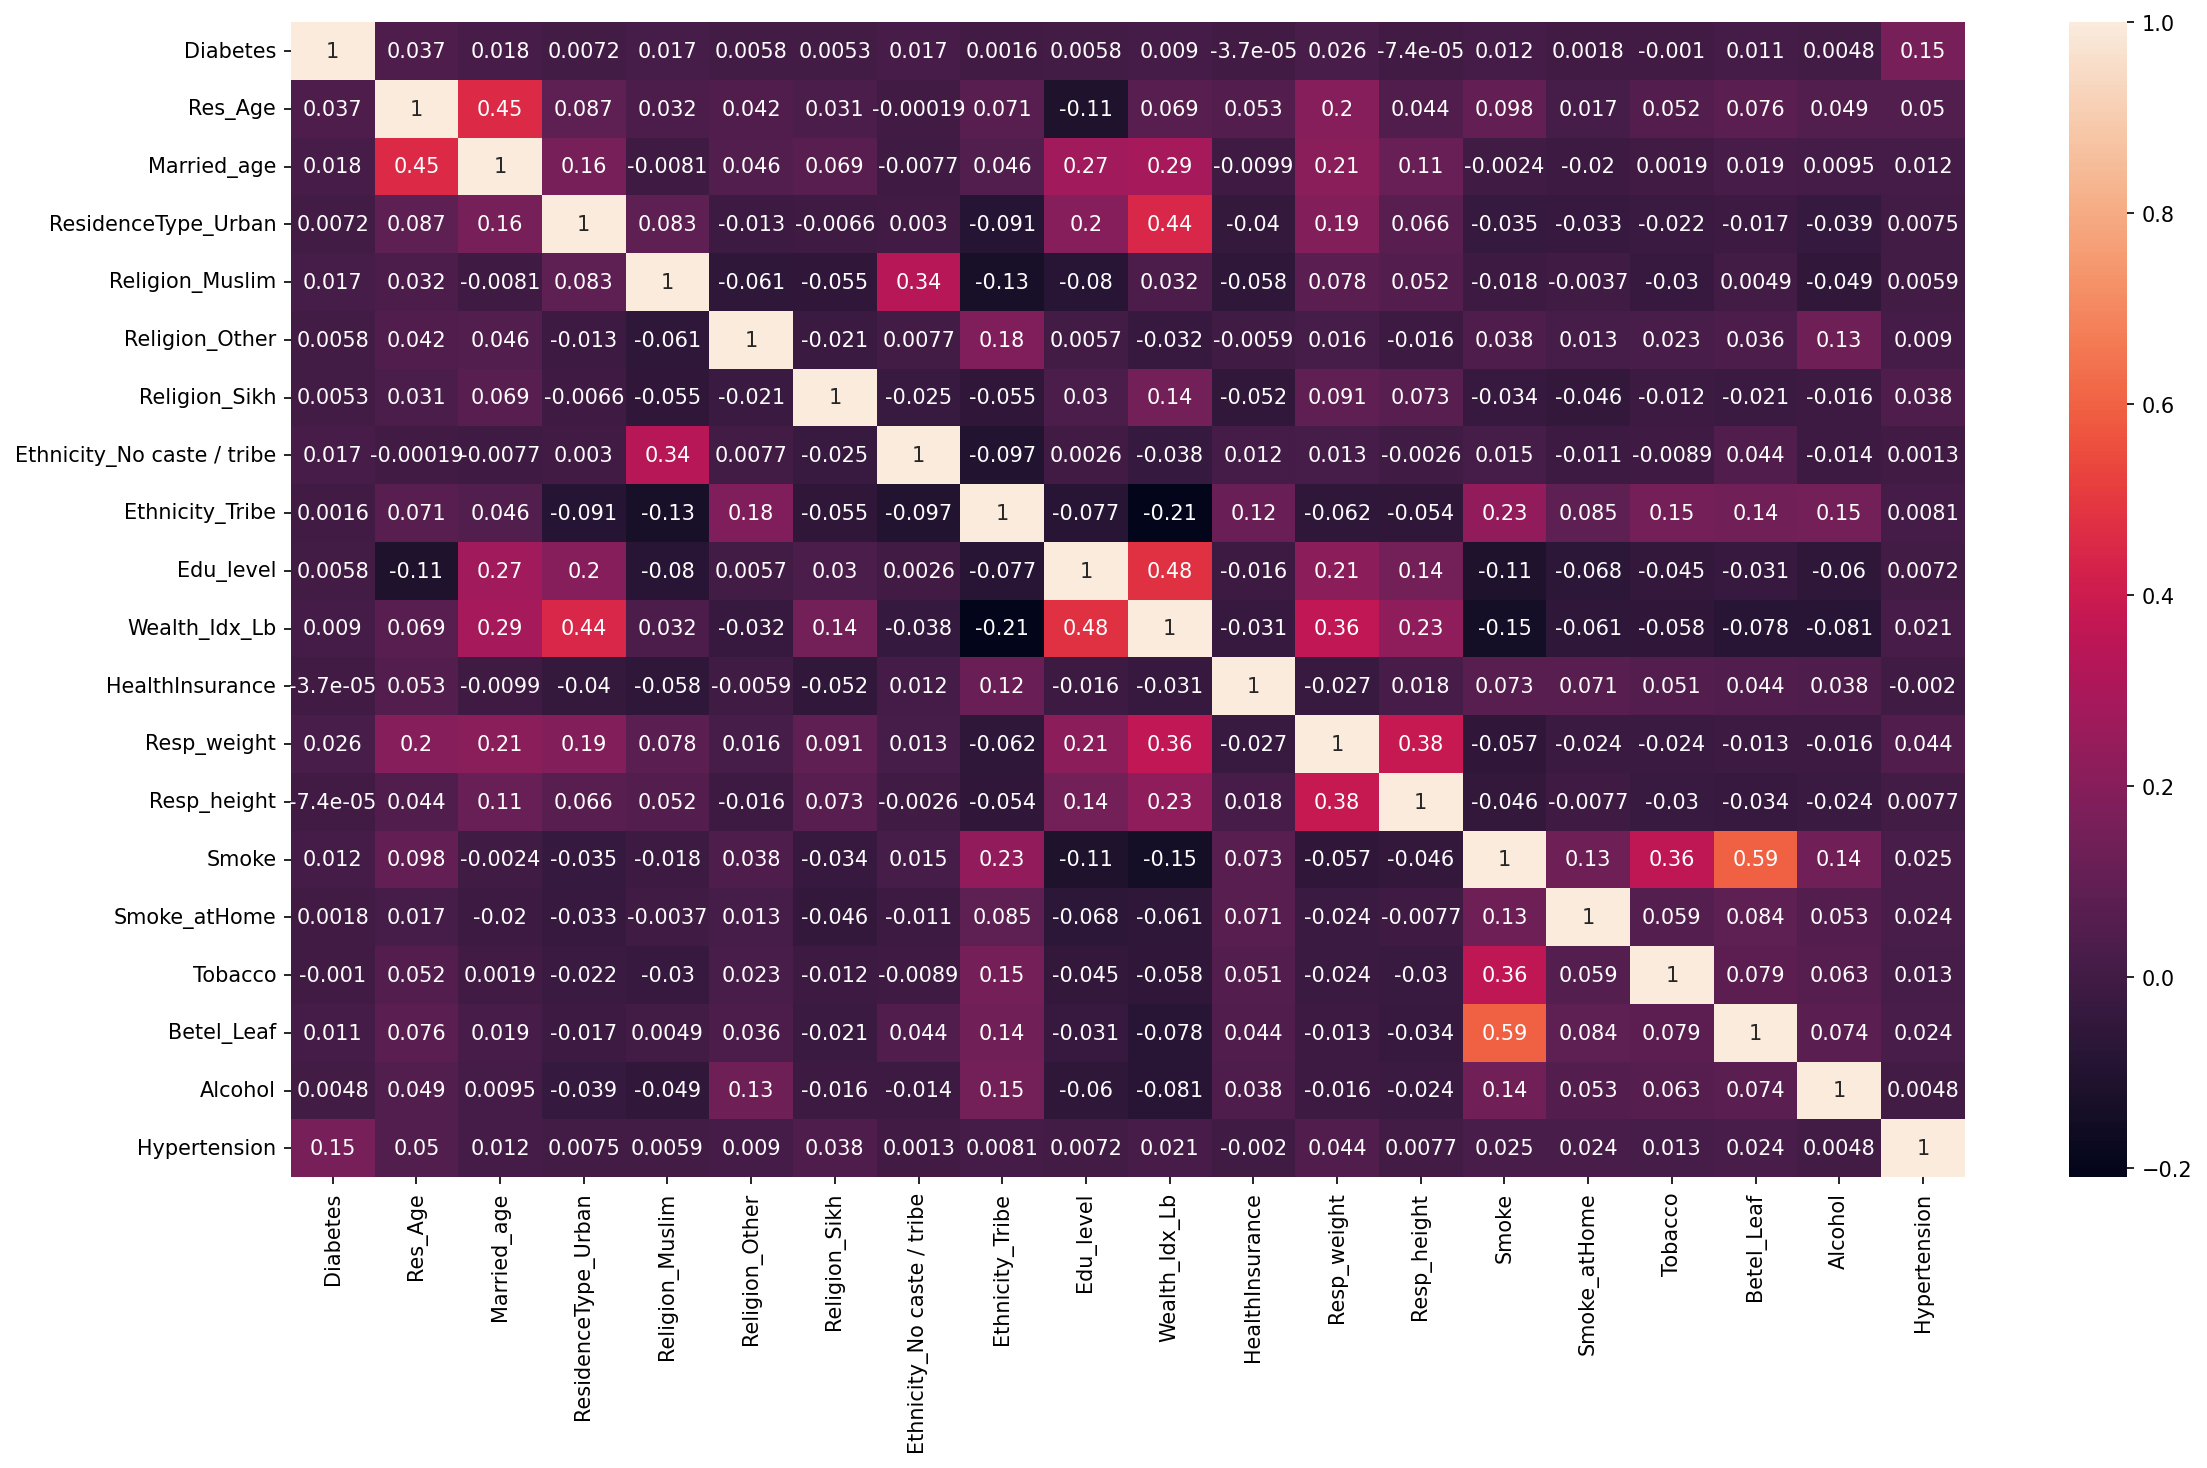

In [154]:
plt.figure(figsize=[18,10],dpi=150)
sns.heatmap(dfc.corr(numeric_only=True),annot=True)
plt.savefig('figures/Initial_corr.png',dpi=500)
print('Saved: figures/Initial_corr.png')

<span style="color: #4CAF50; font-size: 28px; font-weight: bold;">EDA and PREPROCESSING</span>


In [155]:
# ── Missingness check ───────────────────────────────────────────────────
print("Missing values per column:")
print(dfc_copy.isnull().sum()[dfc_copy.isnull().sum() > 0])
print(f"\nRows with ANY missing value: {dfc.isnull().any(axis=1).sum()} / {len(dfc)}")

# ── Check for DHS-style placeholder missing codes (e.g. 98, 99, 9998) ─────
for col in ["Res_Age","Married_age","Edu_level","Wealth_Idx_Lb",
            "Resp_weight","Resp_height"]:
    print(f"\n{col}: min={dfc_copy[col].min()}, max={dfc[col].max()}, "
          f"suspicious high values (>900): {(dfc[col] > 900).sum()}")

# ── Sanity-check categorical encodings actually look like what we assume ──
for col in ["Edu_level"]:
    print(f"\n{col} value counts:\n{dfc[col].value_counts().sort_index()}")

Missing values per column:
Series([], dtype: int64)

Rows with ANY missing value: 0 / 136136

Res_Age: min=15, max=49, suspicious high values (>900): 0

Married_age: min=0, max=47, suspicious high values (>900): 0

Edu_level: min=0, max=3, suspicious high values (>900): 0

Wealth_Idx_Lb: min=0, max=4, suspicious high values (>900): 0

Resp_weight: min=15.0, max=164.4, suspicious high values (>900): 0

Resp_height: min=0.8, max=2.078, suspicious high values (>900): 0

Edu_level value counts:
Edu_level
0    25354
1    16357
2    73561
3    20864
Name: count, dtype: int64


In [151]:
df['Married_age'].value_counts().sort_index().head(10)

Married_age
0       5
1       1
2       1
4       1
5       2
6       1
7       5
8      11
9      17
10    224
Name: count, dtype: int64

In [13]:
# ── 1. How many "never married" (Married_age = 0)? ─────────────────────────
never_married = (dfc["Married_age"] == 0).sum()
print(f"Married_age == 0: {never_married:,} rows ({never_married/len(dfc):.1%})")
print(dfc["Married_age"].value_counts().sort_index().head(5))

# ── 2. How many implausible heights/weights? ────────────────────────────────
# Realistic adult female bounds: height 1.2m–2.1m, weight 25kg–160kg
bad_height = (dfc["Resp_height"] < 1.2).sum()
bad_weight = (dfc["Resp_weight"] < 25).sum()
print(f"\nResp_height < 1.2m: {bad_height:,} rows")
print(f"Resp_weight < 25kg : {bad_weight:,} rows")

# distribution of the low tail specifically
print("\nLowest 10 height values:", sorted(dfc['Resp_height'])[:10])
print("Lowest 10 weight values:", sorted(dfc['Resp_weight'])[:10])

# do bad height and bad weight tend to occur on the SAME rows?
# (helps tell us if it's one corrupted record-batch vs scattered noise)
overlap = ((dfc["Resp_height"] < 1.2) & (dfc["Resp_weight"] < 25)).sum()
print(f"\nRows with BOTH implausible height AND weight: {overlap:,}")

Married_age == 0: 5 rows (0.0%)
Married_age
0    5
1    1
2    1
4    1
5    2
Name: count, dtype: int64

Resp_height < 1.2m: 137 rows
Resp_weight < 25kg : 17 rows

Lowest 10 height values: [0.8, 0.818, 0.82, 0.822, 0.835, 0.843, 0.86, 0.865, 0.882, 0.962]
Lowest 10 weight values: [15.0, 15.0, 15.0, 15.0, 17.0, 17.3, 20.1, 20.3, 20.9, 21.4]

Rows with BOTH implausible height AND weight: 3


In [14]:
# ── Drop rows with implausible mmeasurement values ────────────────────
before = len(dfc)

dfc = dfc[
    dfc["Resp_height"].between(1.2, 2.1) &
    dfc["Resp_weight"].between(25, 160) &
    ((dfc["Married_age"] >= 10) | (dfc["Married_age"].isna()))
].copy()

print(f"Rows before: {before:,}")
print(f"Rows after : {len(dfc):,}  (dropped {before - len(dfc):,}, "
      f"{(before-len(dfc))/before:.2%})")

Rows before: 136,136
Rows after : 135,939  (dropped 197, 0.14%)


In [15]:
print("Shape:",dfc.shape)
print("\nDtypes:\n", dfc.dtypes)

Shape: (135939, 21)

Dtypes:
 Diabetes                        int64
State                          object
Res_Age                         int64
Married_age                     int64
ResidenceType_Urban             int64
Religion_Muslim                 int64
Religion_Other                  int64
Religion_Sikh                   int64
Ethnicity_No caste / tribe      int64
Ethnicity_Tribe                 int64
Edu_level                       int64
Wealth_Idx_Lb                   int64
HealthInsurance                 int64
Resp_weight                   float64
Resp_height                   float64
Smoke                           int64
Smoke_atHome                    int64
Tobacco                         int64
Betel_Leaf                      int64
Alcohol                         int64
Hypertension                    int64
dtype: object


## <span style="color: #FF9800; font-size: 28px; font-weight: bold;">Categorical data(Binary 0/1) analysis</span>



--- Target distribution ---
Prevalence: 0.90%


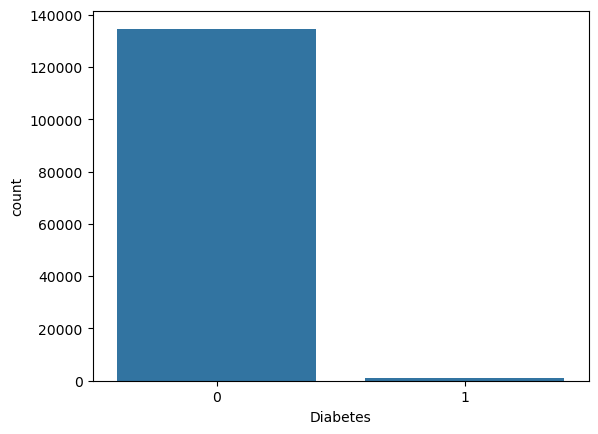

In [16]:
print("\n--- Target distribution ---")
sns.countplot(x='Diabetes', data=dfc)
print(f"Prevalence: {dfc['Diabetes'].mean():.2%}")

For categorical data:- Using count plot for each


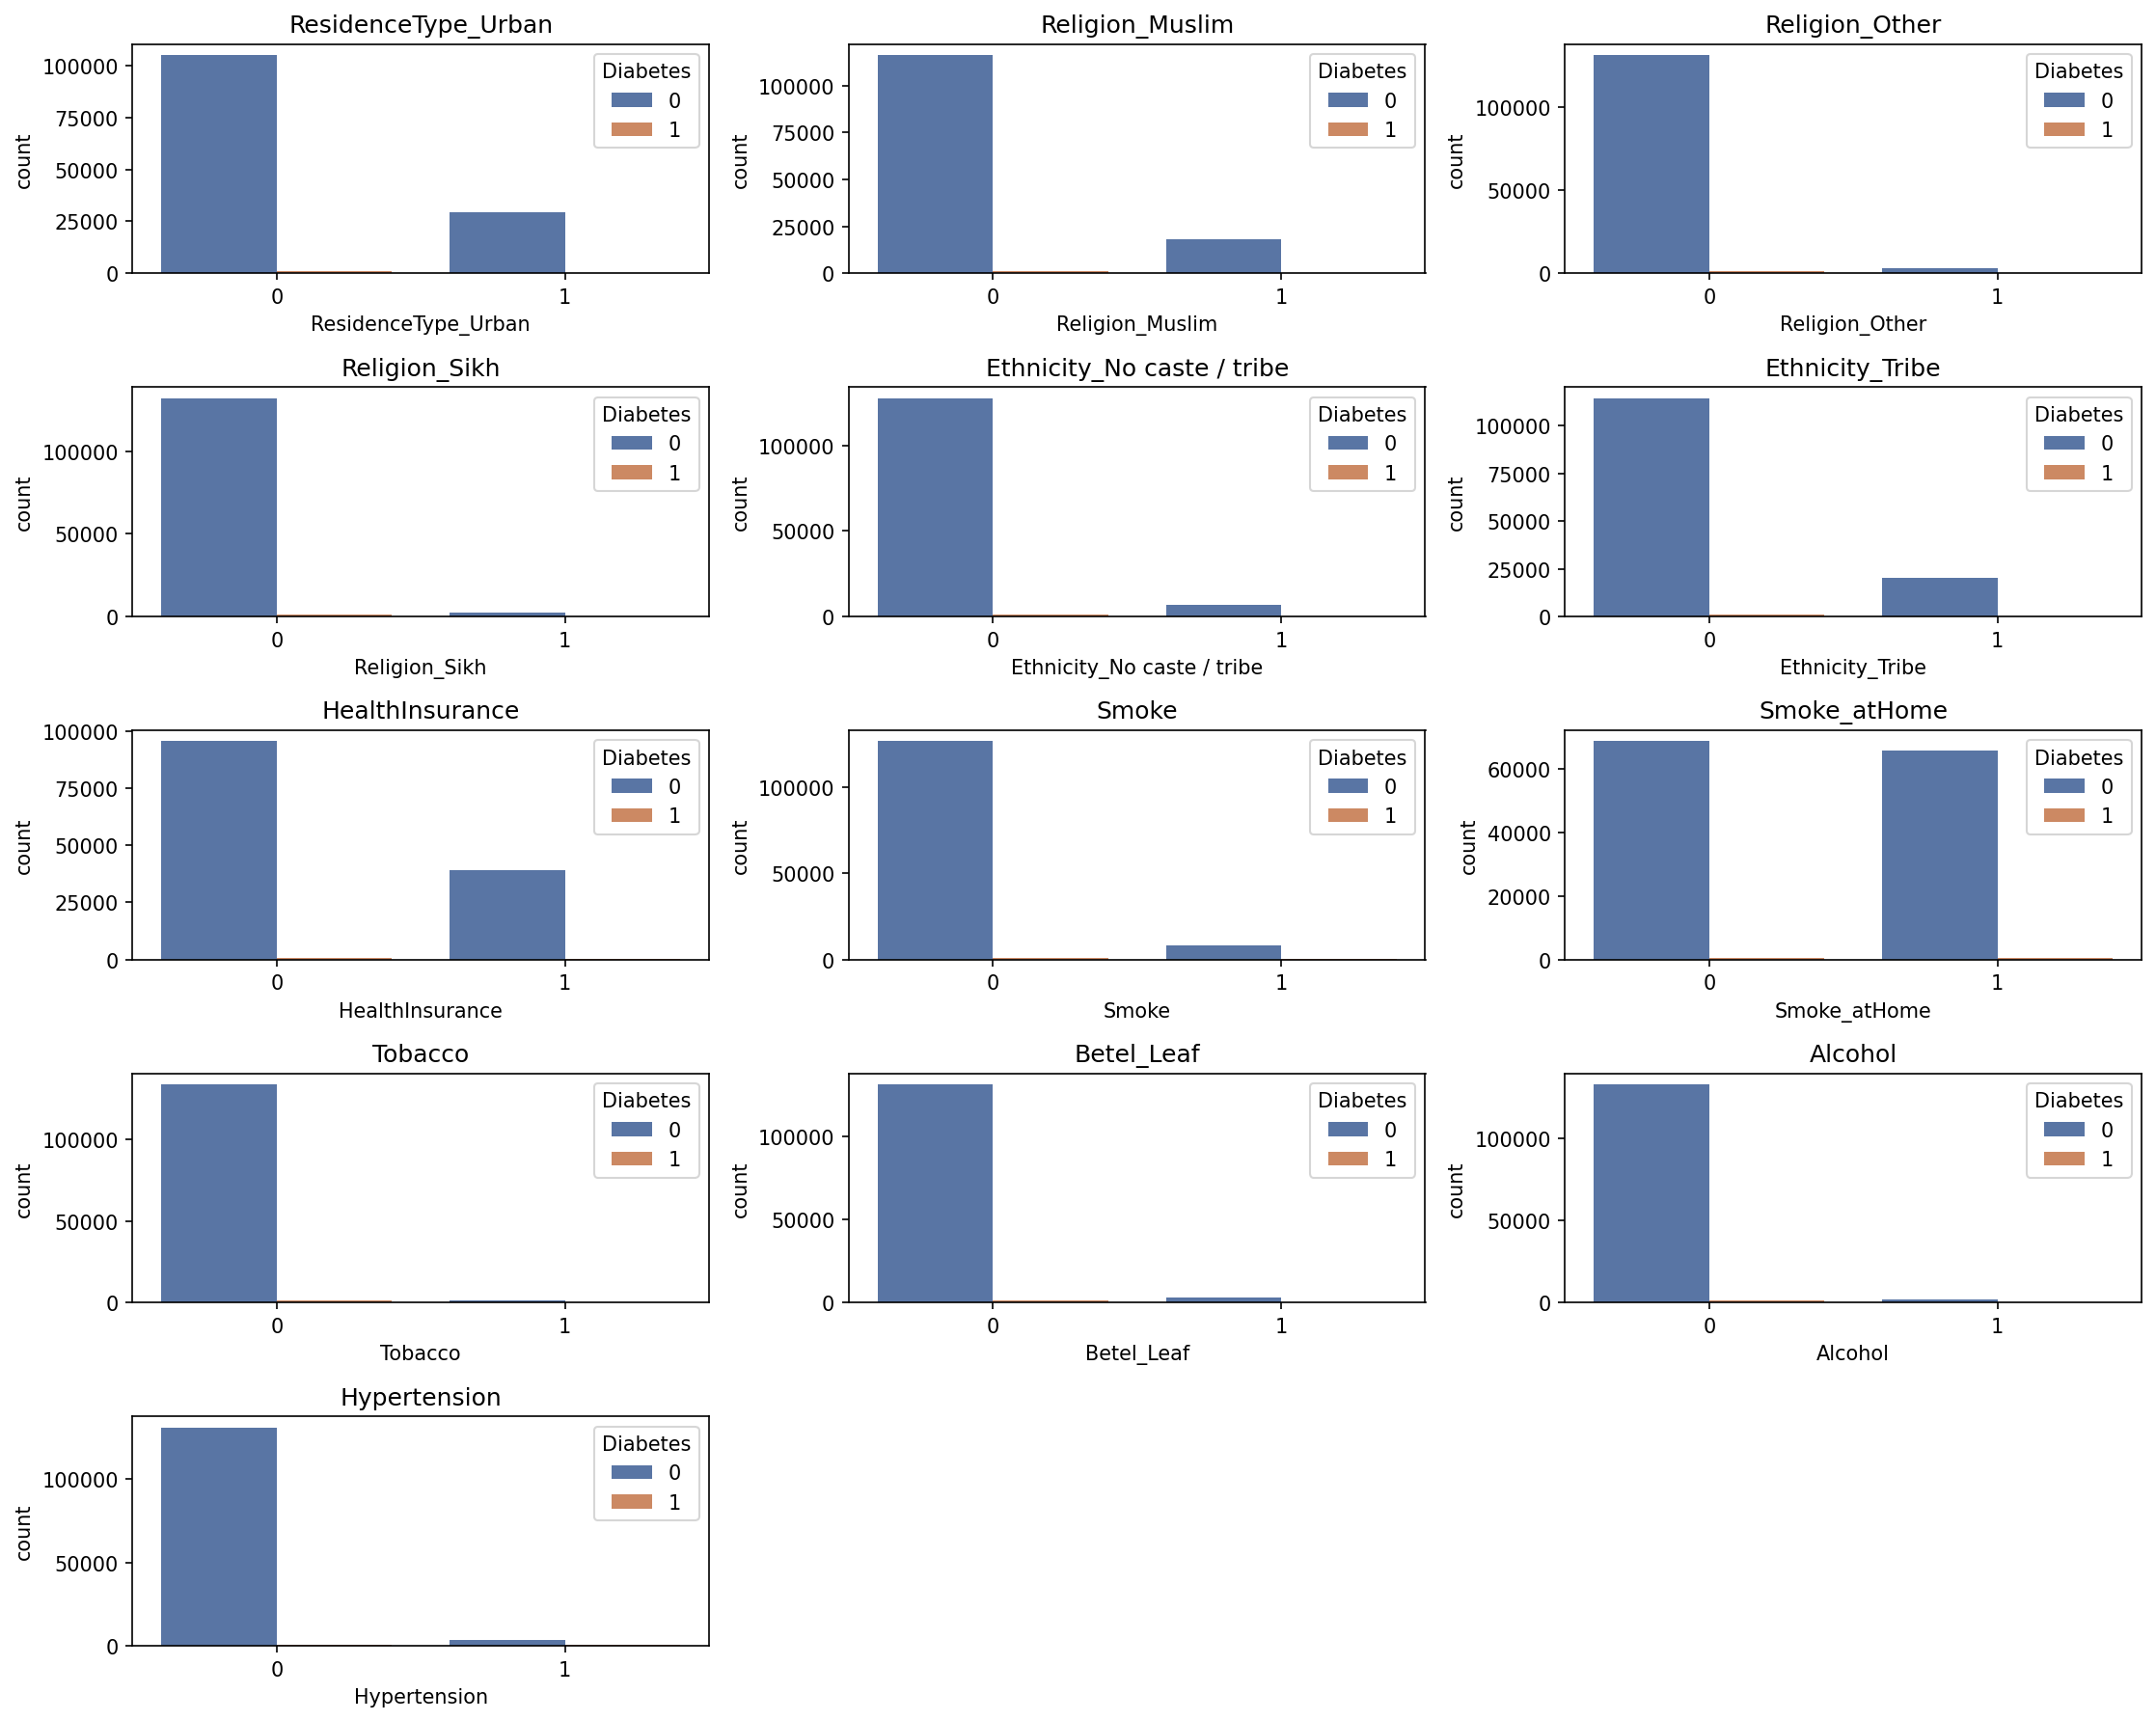

In [17]:
print("For categorical data:- Using count plot for each")

binary_cols = [
    "ResidenceType_Urban","Religion_Muslim","Religion_Other","Religion_Sikh","Ethnicity_No caste / tribe",
    "Ethnicity_Tribe","HealthInsurance","Smoke","Smoke_atHome","Tobacco","Betel_Leaf",
    "Alcohol","Hypertension"
]

plt.figure(figsize=(15,12),dpi=150)

for num, column in enumerate(binary_cols, start=1):

    plt.subplot(5,3,num)

    sns.countplot(
        x=column,
        hue='Diabetes',
        data=dfc,palette=['#4C72B0', '#DD8452']
    )

    plt.title(column)

plt.tight_layout()
plt.savefig(
    "figures/categorical_analysis.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


## Lift analysis for Categorical data

In [156]:
print(f"{'Variable':<28} {'Rate @ 0':>10} {'Rate @ 1':>10} {'Lift':>8}")
print("-" * 60)
for col in binary_cols:
    rate0 = dfc.loc[dfc[col]==0, "Diabetes"].mean()
    rate1 = dfc.loc[dfc[col]==1, "Diabetes"].mean()
    lift = rate1 / rate0 if rate0 > 0 else float("nan")
    print(f"{col:<28} {rate0:>9.2%} {rate1:>9.2%} {lift:>7.2f}x")

Variable                       Rate @ 0   Rate @ 1     Lift
------------------------------------------------------------
ResidenceType_Urban              0.87%     1.03%    1.19x
Religion_Muslim                  0.84%     1.31%    1.56x
Religion_Other                   0.89%     1.26%    1.41x
Religion_Sikh                    0.89%     1.27%    1.41x
Ethnicity_No caste / tribe       0.86%     1.61%    1.86x
Ethnicity_Tribe                  0.89%     0.94%    1.05x
HealthInsurance                  0.90%     0.90%    1.00x
Smoke                            0.87%     1.35%    1.55x
Smoke_atHome                     0.89%     0.92%    1.04x
Tobacco                          0.90%     0.80%    0.88x
Betel_Leaf                       0.89%     1.61%    1.82x
Alcohol                          0.90%     1.26%    1.41x
Hypertension                     0.64%     9.13%   14.22x


In [157]:

# ── State coverage — critical for the stratified split ─────────────────────
state_counts = dfc["State"].value_counts()
print(f"\nTotal unique states: {dfc['State'].nunique()}")
print(f"\nSmallest 10 states by sample size:")
print(state_counts.tail(10))

# how many state×diabetic combos would be too small to stratify on (<2 members)?
strat_key = dfc["State"].astype(str) + "_" + dfc["Diabetes"].astype(str)
rare_combos = (strat_key.value_counts() < 2).sum()
print(f"\nState×Diabetes combos with <2 members: {rare_combos}")


Total unique states: 36

Smallest 10 states by sample size:
State
Tripura                                 1492
Nagaland                                1082
Puducherry                               537
Dadra & Nagar Haveli And Daman & Diu     525
Sikkim                                   426
Ladakh                                   364
Goa                                      266
Lakshadweep                              231
Andaman & Nicobar Islands                212
Chandigarh                               107
Name: count, dtype: int64

State×Diabetes combos with <2 members: 2


<span style="color: #4CAF50; font-size: 28px; font-weight: bold;"> FEATURE ENGINEERING</span>


In [19]:
dfc["BMI"] = dfc["Resp_weight"] / (dfc["Resp_height"] ** 2)

print("\nBMI summary after derivation:")
print(dfc["BMI"].describe())

# safety-net filter: clinically implausible BMI even after clean height/weight
bmi_bad = (~dfc["BMI"].between(12, 60)).sum()
print(f"\nBMI outside 12-60 range: {bmi_bad} rows")
if bmi_bad > 0:
    dfc = dfc[dfc["BMI"].between(12, 60)].copy()
    print(f"Final shape after BMI filter: {dfc.shape}")

# we can now drop the raw weight/height columns — BMI supersedes them
dfc = dfc.drop(columns=["Resp_weight", "Resp_height"])
print(f"\nFinal model-ready shape: {dfc.shape}")


BMI summary after derivation:
count    135939.000000
mean         22.015981
std           4.099443
min           8.617273
25%          19.206627
50%          21.444743
75%          24.077828
max          77.514648
Name: BMI, dtype: float64

BMI outside 12-60 range: 128 rows
Final shape after BMI filter: (135811, 22)

Final model-ready shape: (135811, 20)


In [20]:
# 1. BMI category — Asian-specific WHO cutoffs (not global 18.5/25/30)
def bmi_category(bmi):
    if bmi < 18.5:   return 0  # Underweight
    elif bmi < 23.0: return 1  # Normal
    elif bmi < 27.5: return 2  # Overweight
    else:            return 3  # Obese

dfc["BMI_Category"] = dfc["BMI"].apply(bmi_category)
print("BMI_Category distribution:")
print(dfc["BMI_Category"].value_counts().sort_index())

BMI_Category distribution:
BMI_Category
0    24476
1    65801
2    33072
3    12462
Name: count, dtype: int64


In [21]:
# 2. Age band — standard 5-year reproductive-age groups (matches NFHS reporting convention)
age_bins = [15, 20, 25, 30, 35, 40, 45, 50]
age_labels = [0, 1, 2, 3, 4, 5, 6]  # 15-19, 20-24, ..., 45-49
dfc["Age_Group"] = pd.cut(dfc["Res_Age"], bins=age_bins, labels=age_labels,
                            right=False, include_lowest=True).astype(int)
print("\nAge_Group distribution:")
print(dfc["Age_Group"].value_counts().sort_index())


Age_Group distribution:
Age_Group
0     3577
1    37446
2    52657
3    28032
4    10947
5     2506
6      646
Name: count, dtype: int64


In [22]:
# 3. Years since marriage
dfc["Years_Married"] = dfc["Res_Age"] - dfc["Married_age"]
neg = (dfc["Years_Married"] < 0).sum()
print(f"\nNegative Years_Married (data issue if >0): {neg}")
print(dfc["Years_Married"].describe())


Negative Years_Married (data issue if >0): 0
count    135811.000000
mean          7.820015
std           4.782922
min           0.000000
25%           4.000000
50%           7.000000
75%          10.000000
max          38.000000
Name: Years_Married, dtype: float64


In [23]:
# quick check: does diabetes rate actually rise with BMI category / age group,
# as we'd clinically expect? Good sanity check on whether engineering worked.
print("\nDiabetes rate by BMI category:")
print(dfc.groupby("BMI_Category")["Diabetes"].mean())
print("\nDiabetes rate by Age group:")
print(dfc.groupby("Age_Group")["Diabetes"].mean())


Diabetes rate by BMI category:
BMI_Category
0    0.006414
1    0.007979
2    0.010643
3    0.015086
Name: Diabetes, dtype: float64

Diabetes rate by Age group:
Age_Group
0    0.006710
1    0.006436
2    0.007881
3    0.009739
4    0.016808
5    0.025938
6    0.030960
Name: Diabetes, dtype: float64


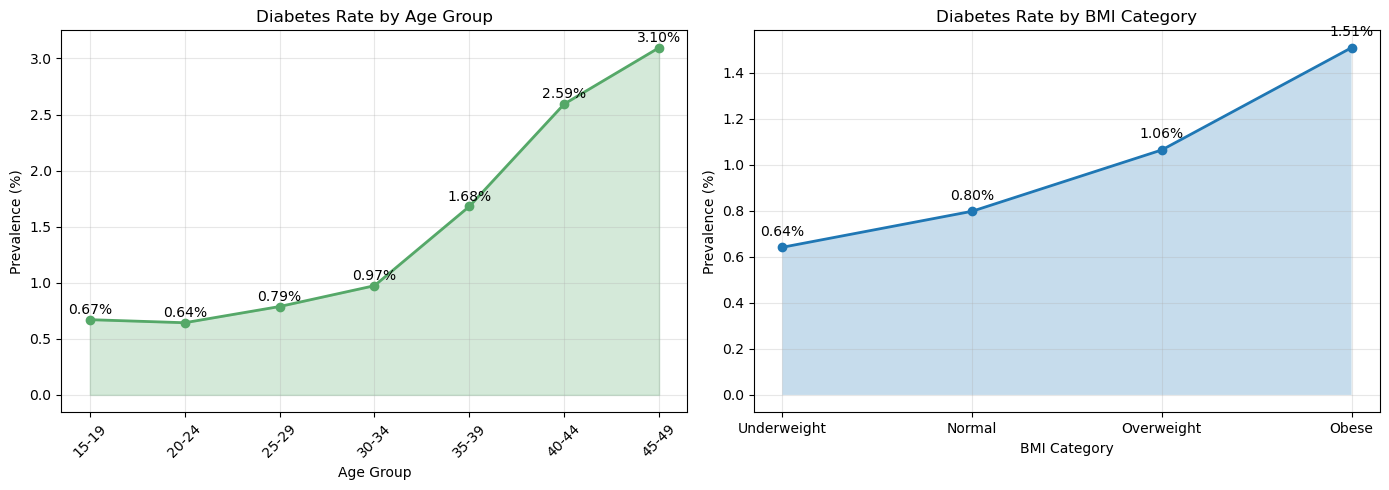

In [24]:
age_prev = (
    dfc.groupby("Age_Group")["Diabetes"]
    .mean()
    .mul(100)
)

bmi_prev = (
    dfc.groupby("BMI_Category")["Diabetes"]
    .mean()
    .mul(100)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ===================== Age Plot =====================
axes[0].plot(
    age_prev.index,
    age_prev.values,
    marker="o",
    linewidth=2,color="#55A868"
)

axes[0].fill_between(
    age_prev.index,
    age_prev.values,
    alpha=0.25,color="#55A868"
)

axes[0].set_title("Diabetes Rate by Age Group")
axes[0].set_xlabel("Age Group")
axes[0].set_ylabel("Prevalence (%)")

axes[0].set_xticks([0,1,2,3,4,5,6])
axes[0].set_xticklabels([
    "15-19",
    "20-24",
    "25-29",
    "30-34",
    "35-39",
    "40-44",
    "45-49"
], rotation=45)

axes[0].grid(alpha=0.3)

# Add percentage labels
for x, y in zip(age_prev.index, age_prev.values):
    axes[0].text(x, y+0.05, f"{y:.2f}%", ha="center")

# ===================== BMI Plot =====================
axes[1].plot(
    bmi_prev.index,
    bmi_prev.values,
    marker="o",
    linewidth=2
)

axes[1].fill_between(
    bmi_prev.index,
    bmi_prev.values,
    alpha=0.25
)

axes[1].set_title("Diabetes Rate by BMI Category")
axes[1].set_xlabel("BMI Category")
axes[1].set_ylabel("Prevalence (%)")

axes[1].set_xticks([0,1,2,3])
axes[1].set_xticklabels([
    "Underweight",
    "Normal",
    "Overweight",
    "Obese"
])

axes[1].grid(alpha=0.3)

# Add percentage labels
for x, y in zip(bmi_prev.index, bmi_prev.values):
    axes[1].text(x, y+0.05, f"{y:.2f}%", ha="center")

plt.tight_layout()

plt.savefig(
    "figures/age_bmi_prevalence.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

<span style="color: #FF9800; font-size: 28px; font-weight: bold;">STRATIFIED ANALYSIS</span>

In [25]:
# ── State coverage — critical for the stratified split ─────────────────────
state_counts = dfc["State"].value_counts()
print(f"\nTotal unique states: {dfc['State'].nunique()}")
print(f"\nSmallest 10 states by sample size:")
print(state_counts.tail(10))

# how many state×diabetic combos would be too small to stratify on (<2 members)?  #cant be stratified
strat_key = dfc["State"].astype(str) + "_" + dfc["Diabetes"].astype(str)
rare_combos = (strat_key.value_counts() < 2).sum()
print(f"\nState×Diabetes combos with <2 members: {rare_combos}")


Total unique states: 36

Smallest 10 states by sample size:
State
Tripura                                 1489
Nagaland                                1081
Puducherry                               537
Dadra & Nagar Haveli And Daman & Diu     524
Sikkim                                   425
Ladakh                                   364
Goa                                      266
Lakshadweep                              230
Andaman & Nicobar Islands                212
Chandigarh                               107
Name: count, dtype: int64

State×Diabetes combos with <2 members: 2


In [26]:
# ── Find and handle the 2 rare state×diabetes combos ────────────────────
strat_key = dfc["State"].astype(str) + "_" + dfc["Diabetes"].astype(str)
combo_counts = strat_key.value_counts()
rare = combo_counts[combo_counts < 2]
print("Rare combos:\n", rare)

# merge just these into a single bucket so stratified split doesn't crash
strat_key_fixed = strat_key.where(~strat_key.isin(rare.index), "rare_group")

Rare combos:
 Dadra & Nagar Haveli And Daman & Diu_1    1
Chandigarh_1                              1
Name: count, dtype: int64


<h1 style="color: #DC143C ; border-bottom: 2px solid #4CAF50; padding-bottom: 8px; font-family: 'Segoe UI', sans-serif;">
    TRAIN-TEST SPLIT
</h1>


In [27]:
dfc.shape

(135811, 23)

In [28]:
dfc.head(3)

,Diabetes,State,Res_Age,Married_age,ResidenceType_Urban,Religion_Muslim,Religion_Other,Religion_Sikh,Ethnicity_No caste / tribe,Ethnicity_Tribe,...,Smoke,Smoke_atHome,Tobacco,Betel_Leaf,Alcohol,Hypertension,BMI,BMI_Category,Age_Group,Years_Married
0,0,Jammu & Kashmir,38,26,0,1,0,0,0,0,...,0,0,0,0,0,0,29.174709,3,4,12
1,0,Jammu & Kashmir,39,24,0,1,0,0,0,0,...,0,1,0,0,0,1,22.156618,1,4,15
2,0,Jammu & Kashmir,30,28,0,1,0,0,0,0,...,0,1,0,0,0,0,25.682155,2,3,2


In [29]:
X = dfc.drop(columns=["Diabetes"])
y = dfc["Diabetes"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=strat_key_fixed
)

print(f"\nTrain: {len(X_train):,}  ({y_train.mean():.2%} diabetic)")
print(f"Test : {len(X_test):,}  ({y_test.mean():.2%} diabetic)")
print(f"States in train: {X_train['State'].nunique()}, test: {X_test['State'].nunique()}")


Train: 108,648  (0.90% diabetic)
Test : 27,163  (0.89% diabetic)
States in train: 36, test: 36


In [30]:
# ── Remove State from model features (it was only needed for the split) ───
X_train_state = X_train["State"].copy()   # keep aside, in case you want
X_test_state  = X_test["State"].copy()    # state-level breakdowns later

X_train = X_train.drop(columns=["State"])
X_test  = X_test.drop(columns=["State"])

print("Remaining feature columns:", list(X_train.columns))
print("Any non-numeric columns left?",
      X_train.select_dtypes(exclude="number").columns.tolist())

Remaining feature columns: ['Res_Age', 'Married_age', 'ResidenceType_Urban', 'Religion_Muslim', 'Religion_Other', 'Religion_Sikh', 'Ethnicity_No caste / tribe', 'Ethnicity_Tribe', 'Edu_level', 'Wealth_Idx_Lb', 'HealthInsurance', 'Smoke', 'Smoke_atHome', 'Tobacco', 'Betel_Leaf', 'Alcohol', 'Hypertension', 'BMI', 'BMI_Category', 'Age_Group', 'Years_Married']
Any non-numeric columns left? []


In [160]:
X_train.shape

(108648, 19)

In [166]:
y_test.value_counts()

Diabetes
0    26921
1      242
Name: count, dtype: int64

In [ ]:
# ── Drop the binned versions from modeling features (redundant with raw) ──
X_train = X_train.drop(columns=["BMI_Category", "Age_Group"])
X_test  = X_test.drop(columns=["BMI_Category", "Age_Group"])

print(f"Final feature count: {X_train.shape[1]}")
print(list(X_train.columns))

<span style="color: #00E5FF  ; font-size: 28px; font-weight: bold;">MODELS PREPARING</span>

In [36]:
X_train.shape[0]

108648

In [90]:
models={
                   #Models with scaling
    
    'Logistic Regression': {
    "model":LogisticRegression(max_iter=1000,random_state=42,solver='saga'),
        "params":{
            "C":[0.01,0.1,1,5],
            "penalty":["l2","l1"]
        },
        "need_scaling":True,
        "support_cw":True
    },

    'SVM(RBF)': {
    "model": SVC(kernel='rbf',random_state=42,cache_size=1000,probability=True),
        "params":{
            "C":[0.01,1,5,10],
            "gamma":['scale','auto']
        },
        "need_scaling":True,
        "support_cw":True
    },

                     #Models without scaling
    
##Random Forest
    'Random Forest ': {
    "model": RandomForestClassifier(random_state=42,n_jobs=1),
        "params":{
            "n_estimators":[200,500],
            "max_depth":[5,10],
            "min_samples_leaf":[2,5,7]
        },
        "need_scaling":False,
        "support_cw":True,
    },
##Naive bayes
    'Naive Bayes': {
    "model": GaussianNB(),
        "params":{
            "var_smoothing": [1e-9, 1e-8, 1e-7],
        },
        "need_scaling":False,
        "support_cw":False
    },
##ADA boosting
    'ADA Boosting': {
    "model": AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1),random_state=42,algorithm='SAMME'),
        "params":{
            "n_estimators":[50,100,200],
            "learning_rate":[0.01,0.1,0.5,1],
        },
        "need_scaling":False,
        "support_cw":False
    },
##XG boost
    'XG Boost': {
    "model": XGBClassifier(random_state=42,n_jobs=-1,eval_metric="logloss",scale_pos_weight=110),
        "params":{
            "n_estimators": [100, 200],
            "learning_rate": [0.05, 0.1],
            "max_depth": [3, 5],
            "subsample": [0.8, 1.0]
        },
        "need_scaling":False,
        "support_cw":False
    }
    
}

In [91]:
#working check of grid
print(f"{'Model':<25} {'Combos':>5} {'Strategies':>15} {'Total fits':>15}")
print("-"*65)
total=0
for name,d_values in models.items():
    n_combos=1
    for j in d_values["params"].values():
        n_combos *=len(j)
    n_strategy=3 if d_values["support_cw"] else 2
    fits=n_combos*n_strategy*5
    total+=fits
    print(f"{name:<25} {n_combos:>5} {n_strategy:>15} {fits:>15}")
print("-"*65)
print(f"{'TOtal time models fit: '}{total}")

Model                     Combos      Strategies      Total fits
-----------------------------------------------------------------
Logistic Regression           8               3             120
SVM(RBF)                      8               3             120
Random Forest                12               3             180
Naive Bayes                   3               2              30
ADA Boosting                 12               2             120
XG Boost                     16               2             160
-----------------------------------------------------------------
TOtal time models fit: 730


## <span style="color: #4CAF50; font-size: 28px; font-weight: bold;">Model Training — GridSearchCV with Pipeline (Scaler + SMOTE inside CV)</span>


**Important:** Both `StandardScaler` and `SMOTE` are placed **inside** the `ImbPipeline`.
This means they are applied **per cross-validation fold**, which prevents data leakage:

- Scaling is fit only on the training fold, then applied to the validation fold.
- SMOTE creates synthetic samples only from the training fold (never the validation fold).

### Three imbalance strategies
1. **none** — train on raw data (no SMOTE, no class_weight)
2. **smote** — SMOTE oversampling inside the pipeline
3. **class_weight** — set `class_weight='balanced'` (only for models that support it)

### SVM cap
SVM is capped to **15 000 training rows** for better training time

In [63]:

# ── Setup and imports ─────────────────────────────────────────────────────
import time
import joblib
# ── SVM-only sample cap ───────────────────────────────────────────────────
SVM_SAMPLE_CAP = 15_000
SEED           = 42

X_train_svm,_,y_train_svm,_=train_test_split(X_train,y_train,
                                         train_size=SVM_SAMPLE_CAP, stratify=y_train ,random_state=42)

print(f"Svm only will train on:{SVM_SAMPLE_CAP:,}/{len(X_train):,} Rows")
print(f"ALL Other models will be trained on full:{len(X_train):,} Rows\n")

# Cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# ── Training loop ─────────────────────────────────────────────────────────
results = []
model_store = {}
roc_store = {}

for name, config in models.items():

    Xt_base = X_train_svm if name == "SVM(RBF)" else X_train
    yt_base = y_train_svm if name == "SVM(RBF)" else y_train

    for strategy in ["none", "smote", "class_weight"]:

        if strategy == "class_weight" and not config["support_cw"]:
            continue

        # Build pipeline 
        steps = []
        if config["need_scaling"]:
            steps.append(("scaler", StandardScaler()))
            
        if strategy == "smote":
            steps.append(("smote", SMOTE(random_state=SEED, k_neighbors=5)))

        model = clone(config["model"])
        if strategy == "class_weight":
            model.set_params(class_weight="balanced")
        steps.append(("clf", model))

        pipe = ImbPipeline(steps)
        param_grid = {}

        # MAKING PARAMETER GRID FOR GRID SEARCH CV
        for parameter_name, parameter_values in config["params"].items():
            pipeline_key = f"clf__{parameter_name}"
            param_grid[pipeline_key] = parameter_values
            
        grid = GridSearchCV(pipe, param_grid, cv=cv, scoring="roc_auc", n_jobs=-1, verbose=0)

        print(f"→ {name:<25} | Strategy: {strategy:<15} | n = {len(Xt_base):<6,} | ", end="", flush=True)

        t0 = time.time()
        grid.fit(Xt_base, yt_base)
        elapsed = time.time() - t0

        # ── Evaluate on full test set ─────────────────────────────────────
        best   = grid.best_estimator_
        y_pred = best.predict(X_test)
        
        if hasattr(best, "predict_proba"):
            y_prob = best.predict_proba(X_test)[:, 1]
        else:
            y_prob = best.decision_function(X_test)

        # Store ROC curve data
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        auc_score = roc_auc_score(y_test, y_prob)
        roc_store[(name, strategy)] = (fpr, tpr, auc_score)
        
        # Store fitted model object (just like the reference notebook)
        model_store[(name, strategy)] = best

        # Collect metrics
        results.append({
            "Model"           : name,
            "Strategy"        : strategy,
            "Rows Trained On" : len(Xt_base),
            "Accuracy"        : round(accuracy_score(y_test, y_pred),4),
            "Recall"          : round(recall_score(y_test, y_pred),4),
            "Precision"       : round(precision_score(y_test, y_pred, zero_division=0),4),
            "F1"              : round(f1_score(y_test, y_pred),4),
            "ROC-AUC"         : round(auc_score,4),
            "Log Loss"        : round(log_loss(y_test, y_prob),4),
            "Time (s)"        : round(elapsed, 1),
            "Best Params"     : grid.best_params_,
        })

        print(f"AUC = {results[-1]['ROC-AUC']:.4f}   "
              f"Recall = {results[-1]['Recall']:.4f}   "
              f"F1 = {results[-1]['F1']:.4f}   "
              f"Time = {elapsed:>5.1f}s \n")

# ── Save everything to disk ───────────────────────────────────────────────
import os
os.makedirs("outputs", exist_ok=True)

joblib.dump({
    'results': results,
    'model_store': model_store,
    'roc_store': roc_store
}, "outputs/trained_models_data.pkl")

print("\n✅ Training complete! All fitted models and ROC curves have been saved to 'outputs/trained_models_data.pkl'")



Svm only will train on:15,000/108,648 Rows
ALL Other models will be trained on full:108,648 Rows

→ Logistic Regression       | Strategy: none            | n = 108,648 | AUC = 0.7184   Recall = 0.0000   F1 = 0.0000   Time =  29.7s 

→ Logistic Regression       | Strategy: smote           | n = 108,648 | AUC = 0.7132   Recall = 0.5413   F1 = 0.0494   Time =  55.2s 

→ Logistic Regression       | Strategy: class_weight    | n = 108,648 | AUC = 0.6701   Recall = 0.5661   F1 = 0.0375   Time = 385.7s 

→ SVM(RBF)                  | Strategy: none            | n = 15,000 | AUC = 0.4150   Recall = 0.0165   F1 = 0.0303   Time =  42.3s 

→ SVM(RBF)                  | Strategy: smote           | n = 15,000 | AUC = 0.7169   Recall = 0.4959   F1 = 0.0512   Time = 1436.8s 

→ SVM(RBF)                  | Strategy: class_weight    | n = 15,000 | AUC = 0.7446   Recall = 0.6157   F1 = 0.0412   Time = 428.3s 

→ Random Forest             | Strategy: none            | n = 108,648 | AUC = 0.7277   Recall 

<span style="color: #00E5FF  ; font-size: 28px; font-weight: bold;">EVALUATION</span>

For a diabetes **screening** application, evaluation metrics should be interpreted differently from a normal classification task.

| Metric | Interpretation | Priority for Screening |
|---|---|---|
| Accuracy | % predictions correct overall | <span style="color:#8a6d3b;"><b>Low</b></span> — misleading with 0.9% prevalence |
| <span style="color:#b45309;"><b>Recall</b></span> | % of actual diabetic cases caught | <span style="color:#b45309;"><b>Highest</b></span> — missing a diabetic is the worst error |
| Precision | % of flagged cases truly diabetic | Medium — affects follow-up resource planning |
| <span style="color:#2f6f4e;"><b>F1-Score</b></span> | Harmonic mean of Recall & Precision | <span style="color:#2f6f4e;"><b>High</b></span> — balanced summary |
| <span style="color:#2f6f4e;"><b>ROC-AUC</b></span> | Discrimination ability across all thresholds | <span style="color:#2f6f4e;"><b>High</b></span> — threshold-free summary |
| Log Loss | Calibration of predicted probabilities | Medium |



With only **0.9% diabetes prevalence**, a model predicting **non-diabetic** for everyone achieves about **99.1% accuracy**, while catching **zero** actual diabetics.

</div>

Therefore, **Recall** and **ROC-AUC** are the primary evaluation criteria.

In [72]:
# 1. Converting Results into Datafram for better evaluation
results_df = pd.DataFrame(results)


summary_cols = ["Model", "Rows Trained On","Strategy", "Accuracy", "Recall",
                "Precision", "F1", "ROC-AUC", "Log Loss", "Time (s)"]

# 3. Clean plain-text printout
print("\n── Results Summary:-")



results_df[summary_cols].style.background_gradient(
    subset=["Recall", "ROC-AUC", "F1"], 
    cmap='Greens'
).format(precision=4)


── Results Summary:-


,Model,Rows Trained On,Strategy,Accuracy,Recall,Precision,F1,ROC-AUC,Log Loss,Time (s)
0,Logistic Regression,108648,none,0.9911,0.0000,0.0000,0.0000,0.7184,0.0458,29.7000
1,Logistic Regression,108648,smote,0.8145,0.5413,0.0259,0.0494,0.7132,0.5742,55.2000
2,Logistic Regression,108648,class_weight,0.7411,0.5661,0.0194,0.0375,0.6701,0.7663,385.7000
3,SVM(RBF),15000,none,0.9906,0.0165,0.1818,0.0303,0.4150,0.0510,42.3000
4,SVM(RBF),15000,smote,0.8364,0.4959,0.0270,0.0512,0.7169,0.5092,1436.8000
5,SVM(RBF),15000,class_weight,0.7447,0.6157,0.0213,0.0412,0.7446,0.0466,428.3000
6,Random Forest,108648,none,0.9911,0.0000,0.0000,0.0000,0.7277,0.0455,289.1000
7,Random Forest,108648,smote,0.7108,0.4380,0.0135,0.0263,0.5885,0.5851,736.6000
8,Random Forest,108648,class_weight,0.8662,0.5041,0.0336,0.0629,0.7177,0.5589,324.7000
9,Naive Bayes,108648,none,0.9234,0.4050,0.0482,0.0861,0.7289,0.5891,1.1000


In [73]:
# ── Pivot tables: Metric × Classifier × Strategy ──────────────────────────
for metric in ['ROC-AUC', 'Recall', 'F1']:
    pivot = results_df.pivot_table(
        values=metric, index='Model', columns='Strategy', aggfunc='first'
    ).round(4)
    print(f'\n{metric} — Classifier × Strategy')
    print(pivot.to_string())

# ── Best models ──────────────────────────────────────────────────────────
best_auc = results_df.loc[results_df['ROC-AUC'].idxmax()]
best_rec = results_df.loc[results_df['Recall'].idxmax()]
print(f"\nBest by ROC-AUC : {best_auc['Model']}  [{best_auc['Strategy']}]  AUC={best_auc['ROC-AUC']:.4f}")
print(f"Best by Recall  : {best_rec['Model']}  [{best_rec['Strategy']}]  Recall={best_rec['Recall']:.4f}")



ROC-AUC — Classifier × Strategy
Strategy             class_weight    none   smote
Model                                            
ADA Boosting                  NaN  0.7124  0.6060
Logistic Regression        0.6701  0.7184  0.7132
Naive Bayes                   NaN  0.7289  0.5427
Random Forest              0.7177  0.7277  0.5885
SVM(RBF)                   0.7446  0.4150  0.7169
XG Boost                      NaN  0.7095  0.5247

Recall — Classifier × Strategy
Strategy             class_weight    none   smote
Model                                            
ADA Boosting                  NaN  0.0000  0.4628
Logistic Regression        0.5661  0.0000  0.5413
Naive Bayes                   NaN  0.4050  0.7107
Random Forest              0.5041  0.0000  0.4380
SVM(RBF)                   0.6157  0.0165  0.4959
XG Boost                      NaN  0.5248  0.9339

F1 — Classifier × Strategy
Strategy             class_weight    none   smote
Model                                            
ADA Boo

<h2><span style="color:#FCAE1E; font-size: 28px;">Visual Analysis</span></h2>

To compare model performance clearly, four complementary visualisations are used:

| Visualisation | Purpose |
|---|---|
| <span style="color:#2f6f4e;"><b>ROC Curves</b></span> | Compares discrimination quality across all classifiers and imbalance-handling strategies |
| <span style="color:#b45309;"><b>Recall × ROC-AUC Scatter</b></span> | Identifies models that achieve both high sensitivity and strong discrimination |
| <span style="color:#E60073;"><b>Precision-Recall Curves</b></span> | Evaluates classifier performance under heavy class imbalance by focusing on the minority class |

* These plots are used together because no single visualisation fully captures screening performance.  
* The Precision-Recall curves specifically highlight how well the classifiers maintain precision when dealing with highly skewed class distributions (Unmodified vs. SMOTE vs. Class Weight).
* For this project, the strongest model should show **high Recall** while maintaining a competitive **ROC-AUC**.


In [125]:
#what's actually stored in rroc_store
for key in sorted(roc_store.keys()):
    fpr, tpr, auc = roc_store[key]
    print(f"{key[0]:<25} | {key[1]:<15} | AUC={auc:.4f} | n_thresholds={len(fpr)}")

ADA Boosting              | none            | AUC=0.7124 | n_thresholds=873
ADA Boosting              | smote           | AUC=0.6060 | n_thresholds=1067
Logistic Regression       | class_weight    | AUC=0.6701 | n_thresholds=479
Logistic Regression       | none            | AUC=0.7184 | n_thresholds=481
Logistic Regression       | smote           | AUC=0.7132 | n_thresholds=475
Naive Bayes               | none            | AUC=0.7289 | n_thresholds=471
Naive Bayes               | smote           | AUC=0.5427 | n_thresholds=450
Random Forest             | class_weight    | AUC=0.7177 | n_thresholds=1130
Random Forest             | none            | AUC=0.7277 | n_thresholds=1486
Random Forest             | smote           | AUC=0.5885 | n_thresholds=3723
SVM(RBF)                  | class_weight    | AUC=0.7446 | n_thresholds=468
SVM(RBF)                  | none            | AUC=0.4150 | n_thresholds=479
SVM(RBF)                  | smote           | AUC=0.7169 | n_thresholds=477
XG Boost

# ROC-AUC Curve

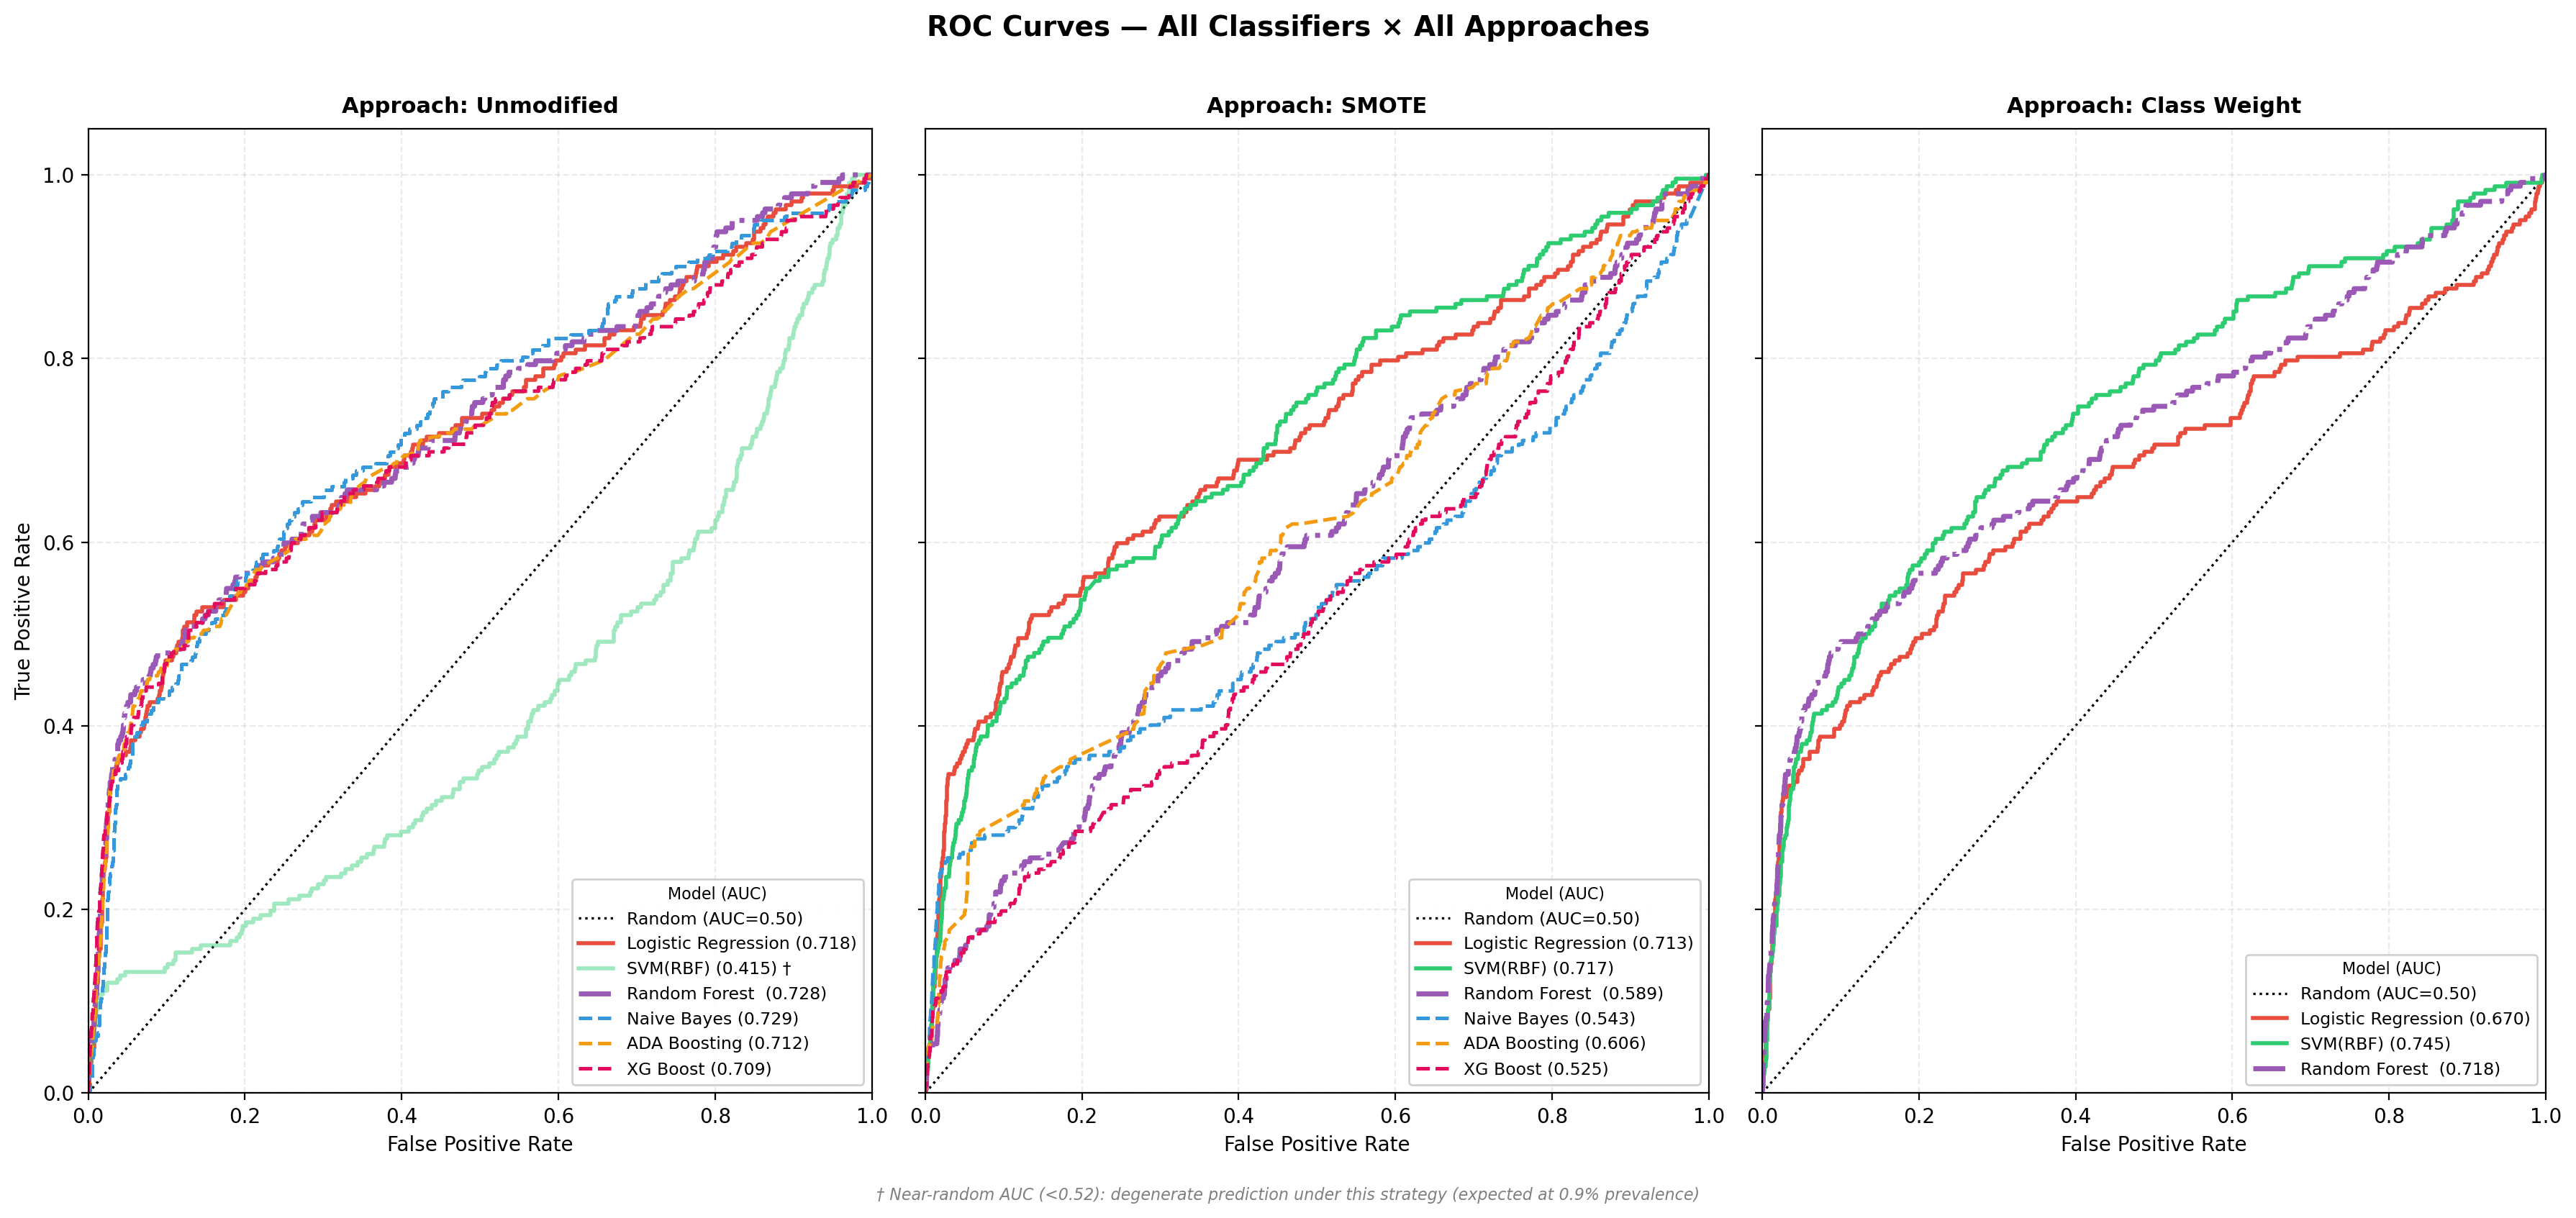

Saved:figures/04_pr_curves.png


In [129]:


# ── Consistent style per model ─────────────────────────────────────────────
model_styles = {
    "Logistic Regression" : {"color": "#E74C3C", "lw": 2.0, "ls": "-"},
    "SVM(RBF)"            : {"color": "#2ECC71", "lw": 2.0, "ls": "-"},
    "Random Forest "       : {"color":"#9B59B6", "lw": 2.5, "ls": "-."},
    "Naive Bayes"         : {"color": "#3498DB", "lw": 1.8, "ls": "--"},
    "ADA Boosting"        : {"color": "#F39C12", "lw": 1.8, "ls": "--"},
    "XG Boost"            : {"color": "#E30B5D", "lw": 1.8, "ls": "--"},
}

strategy_titles = {
    "none"         : "Approach: Unmodified",
    "smote"        : "Approach: SMOTE",
    "class_weight" : "Approach: Class Weight",
}

# Models that support class_weight
cw_supported = {"Logistic Regression", "SVM(RBF)", "Random Forest "}

fig, axes = plt.subplots(1, 3, figsize=(18, 8), sharey=True,dpi=200)
fig.suptitle("ROC Curves — All Classifiers × All Approaches",
             fontsize=14, fontweight="bold", y=1.01)

for ax, strategy in zip(axes, ["none", "smote", "class_weight"]):
    
    ax.plot([0, 1], [0, 1], color="black", lw=1.2, ls=":",
            label="Random (AUC=0.50)", zorder=1)

    for model_name, style in model_styles.items():
        # Skip models that don't have this strategy
        if strategy == "class_weight" and model_name not in cw_supported:
            continue
            
        key = (model_name, strategy)
        if key not in roc_store:
            continue

        fpr, tpr, auc_score = roc_store[key]

        # Flag degenerate curves visually with lower alpha
        alpha = 0.45 if auc_score < 0.52 else 1.0

        label = f"{model_name} ({auc_score:.3f})"
        if auc_score < 0.52:
            label += " †"   # dagger marks degenerate

        ax.plot(fpr, tpr,
                color=style["color"],
                lw=style["lw"],
                ls=style["ls"],
                alpha=alpha,
                label=label,
                zorder=2)

    ax.set_title(strategy_titles[strategy], fontsize=11, fontweight="bold", pad=8)
    ax.set_xlabel("False Positive Rate", fontsize=10)
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.grid(True, alpha=0.25, linestyle="--")
    ax.legend(loc="lower right", fontsize=8.5, framealpha=0.9,
              title="Model (AUC)", title_fontsize=8)

axes[0].set_ylabel("True Positive Rate", fontsize=10)

# Footnote for degenerate marker
fig.text(0.5, -0.02,
         "† Near-random AUC (<0.52): degenerate prediction under this strategy (expected at 0.9% prevalence)",
         ha="center", fontsize=8, color="gray", style="italic")

plt.tight_layout()
plt.savefig("figures/ROC Curves.png", dpi=500, bbox_inches="tight")
plt.show()
print("Saved:figures/04_pr_curves.png")

## PR CURVE

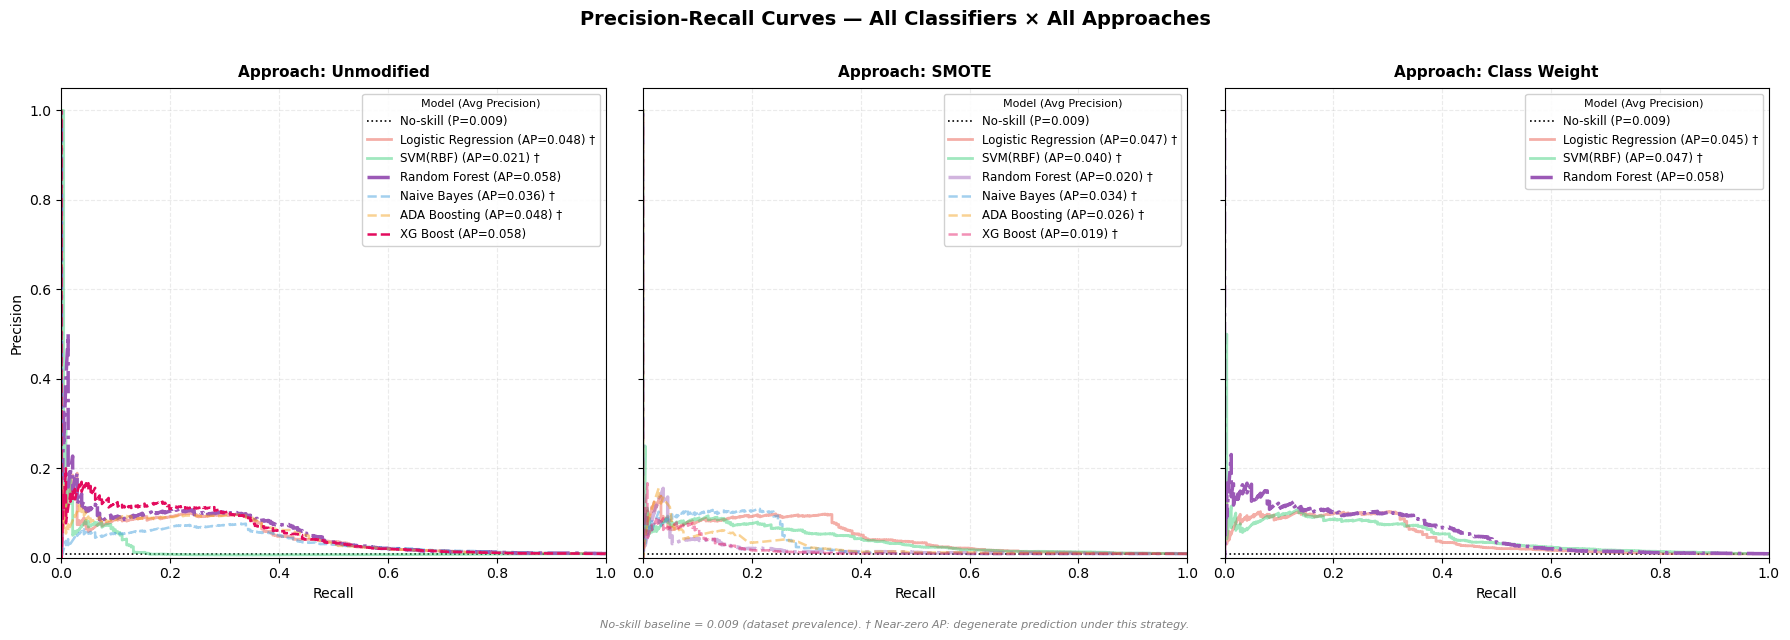

Saved:figures/04_pr_curves.png


In [130]:

# Baseline = actual prevalence
baseline = y_test.mean()

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
fig.suptitle("Precision-Recall Curves — All Classifiers × All Approaches",
             fontsize=14, fontweight="bold", y=1.01)

for ax, strategy in zip(axes, ["none", "smote", "class_weight"]):

    # No-skill baseline (horizontal line at prevalence)
    ax.axhline(y=baseline, color="black", lw=1.2, ls=":",
               label=f"No-skill (P={baseline:.3f})")

    for model_name, style in model_styles.items():
        if strategy == "class_weight" and model_name not in cw_supported:
            continue
            
        key = (model_name, strategy)

        best = model_store[key]

        # Get probabilities
        if hasattr(best, "predict_proba"):
            y_prob = best.predict_proba(X_test)[:, 1]
        else:
            y_prob = best.decision_function(X_test)

        precision, recall, _ = precision_recall_curve(y_test, y_prob)
        ap = average_precision_score(y_test, y_prob)

        # Flag degenerate
        alpha = 0.45 if ap < 0.05 else 1.0
        label = f"{model_name.strip()} (AP={ap:.3f})"
        if ap < 0.05:
            label += " †"

        ax.plot(recall, precision,
                color=style["color"],
                lw=style["lw"],
                ls=style["ls"],
                alpha=alpha,
                label=label)

    ax.set_title(strategy_titles[strategy], fontsize=11, fontweight="bold", pad=8)
    ax.set_xlabel("Recall", fontsize=10)
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.grid(True, alpha=0.25, linestyle="--")
    ax.legend(loc="upper right", fontsize=8.5, framealpha=0.9,
              title="Model (Avg Precision)", title_fontsize=8)

axes[0].set_ylabel("Precision", fontsize=10)

fig.text(0.5, -0.02,
         f"No-skill baseline = {baseline:.3f} (dataset prevalence). "
         "† Near-zero AP: degenerate prediction under this strategy.",
         ha="center", fontsize=8, color="gray", style="italic")
plt.tight_layout()


plt.savefig("figures/PR Curves.png", dpi=500, bbox_inches="tight")
plt.show()
print("Saved:figures/04_pr_curves.png")

## <span style="color:#1f5f8b;">Part 9 — Model Explainability with SHAP</span>

A screening model is only useful if its predictions can be interpreted by clinicians and public-health workers.  
**SHAP (SHapley Additive exPlanations)** helps explain how each feature contributes to a model’s prediction, both at the overall dataset level and for individual respondents.


SHAP helps answer a key question:  
**Which factors pushed the model toward predicting higher or lower diabetes risk?**

</div>

---

### <span style="color:#406882;">Reading a SHAP Beeswarm Plot</span>

| Plot Element | Meaning |
|---|---|
| **Each dot** | One respondent/sample from the test set |
| **X-axis position** | Size and direction of the feature’s effect on prediction |
| **Right side** | Higher contribution toward diabetes risk |
| **Left side** | Higher contribution toward non-diabetes prediction |
| **Colour** | Red = high feature value, blue = low feature value |
| **Feature ranking** | Top features have the highest mean absolute SHAP impact |
| **Wide spread** | Feature has strong but variable influence across respondents |

---

### <span style="color:#406882;">Explainers Used</span>

| Model Type | Explanation Method |
|---|---|
| **Random Forest** | SHAP TreeExplainer |
| **XGBoost** | SHAP TreeExplainer |
| **AdaBoost** | SHAP only if supported; otherwise permutation importance / model-agnostic explainer |
| **Logistic Regression** | Odds ratios from exponentiated coefficients |



SHAP values were calculated on a **stratified random sample of 2,000 test rows** using `seed = 42` to keep computation feasible while preserving class representation.

</div>

---

### <span style="color:#406882;">Expected Clinical Interpretation</span>

| Feature | Expected Finding |
|---|---|
| **BMI** | Likely the strongest predictor, since excess body weight is a major modifiable risk factor for Type-II diabetes |
| **Age** | Expected to rank high, matching the observed rise in prevalence from **0.67% in ages 20–29** to **3.10% in ages 40–49** |
| **Hypertension** | Expected to be a strong binary signal, supported by the observed **14.24× lift** in diabetes prevalence |
| **Wealth Index / Education** | May show protective or mixed patterns due to healthcare access, awareness, and lifestyle differences |
| **Tobacco, Alcohol, Betel Leaf** | May contribute moderately as behavioural risk indicators |
| **Health Insurance** | Expected to have little independent signal, consistent with its near-neutral **1.00× lift** in EDA |



Overall, SHAP is used here to check whether the model’s learned patterns are clinically plausible and consistent with the earlier EDA findings.

</div>

> **Note:** SHAP explains model behaviour, not medical causality. A high SHAP value means the model used that feature strongly, not that the feature directly caused diabetes.

Running SHAP TreeExplainer for tree-based models...

→ Random Forest | strategy=none | computing SHAP values...


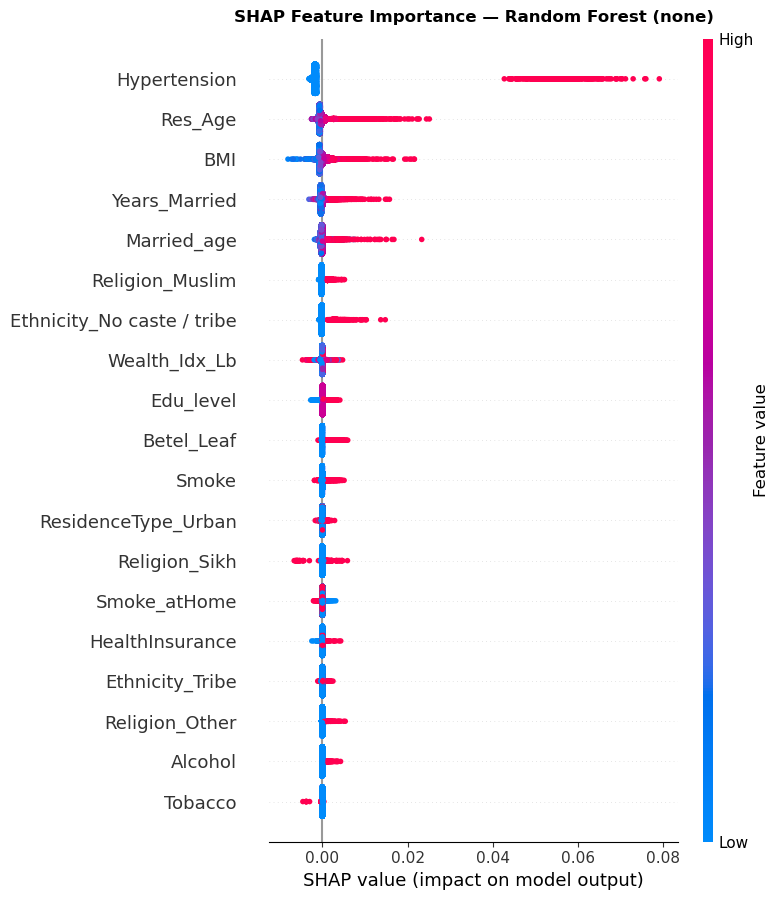

Saved: figures/shap_random_forest_none.png

→ XG Boost | strategy=none | computing SHAP values...


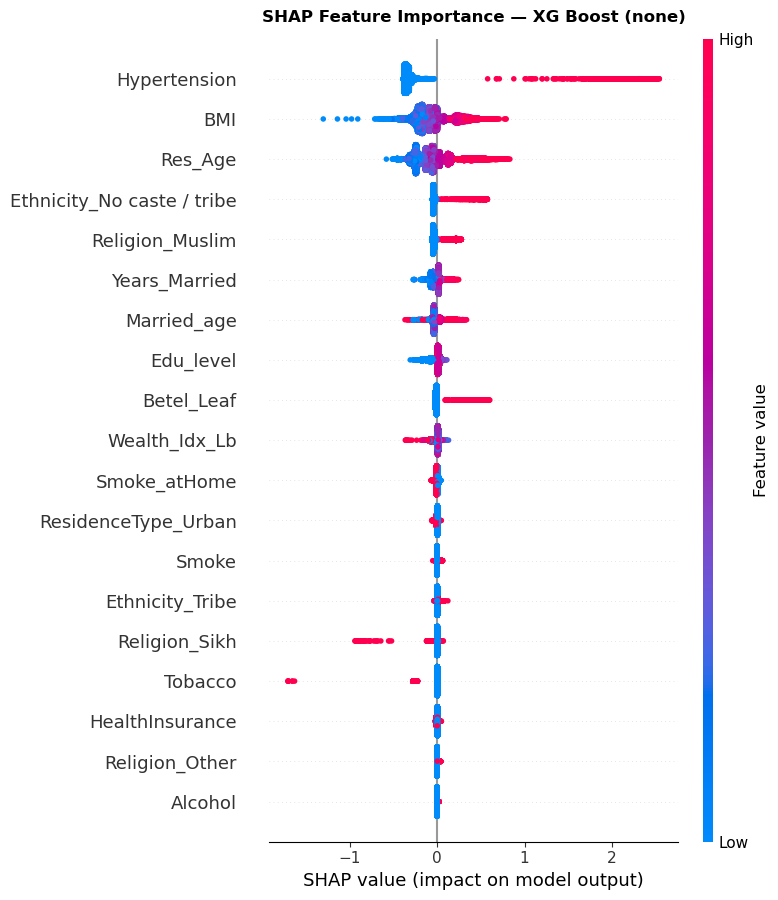

Saved: figures/shap_xg_boost_none.png

✅ SHAP complete for all tree models.


In [119]:

# ── Feature names (strip state column, already removed from X_train) ──────
feature_names = list(X_train.columns)

# ── Which models to explain and with which strategy ───────────────────────
# Using best AUC strategy per model from roc_store analysis
tree_models_to_explain = {
    "Random Forest "  : "none",    # AUC=0.728, trailing space intentional
    "XG Boost"        : "none",    # AUC=0.709
}

# ── SHAP background sample — 500 rows is enough, more = slower ────────────
np.random.seed(42)
bg_idx = np.random.choice(len(X_train), size=500, replace=False)
X_bg   = X_train.iloc[bg_idx]

# ── Explain sample — use full X_test (27K rows is fine for TreeExplainer) ─
X_explain = X_test.copy()

print("Running SHAP TreeExplainer for tree-based models...\n")

shap_store = {}  # store shap_values for later use if needed


for model_name, strategy in tree_models_to_explain.items():
    key = (model_name, strategy)
    best_pipe = model_store[key]
    clf = best_pipe.named_steps["clf"]

    if "scaler" in best_pipe.named_steps:
        X_exp_transformed = pd.DataFrame(
            best_pipe.named_steps["scaler"].transform(X_explain),
            columns=feature_names
        )
        X_bg_transformed = pd.DataFrame(
            best_pipe.named_steps["scaler"].transform(X_bg),
            columns=feature_names
        )
    else:
        X_exp_transformed = pd.DataFrame(X_explain.values, columns=feature_names)
        X_bg_transformed  = pd.DataFrame(X_bg.values,      columns=feature_names)

    print(f"→ {model_name.strip()} | strategy={strategy} | computing SHAP values...", flush=True)

    explainer = shap.TreeExplainer(clf)

    if model_name.strip() == "XG Boost":
        sv_array = explainer.shap_values(X_exp_transformed)
        sv = shap.Explanation(
                values=sv_array,
                base_values=explainer.expected_value,
                data=X_exp_transformed,
                feature_names=feature_names)
    else:
        shap_values = explainer(X_exp_transformed)   # pass DataFrame, names come through
        if len(shap_values.shape) == 3:
            sv = shap_values[:, :, 1]
        else:
            sv = shap_values

    shap_store[key] = sv

    fig, ax = plt.subplots(figsize=(10, 7))
    shap.plots.beeswarm(sv, max_display=19, show=False)
    plt.title(f"SHAP Feature Importance — {model_name.strip()} ({strategy})",
              fontsize=12, fontweight="bold", pad=12)
    plt.tight_layout()

    fname = f"figures/shap_{model_name.strip().replace(' ', '_').lower()}_{strategy}.png"
    plt.savefig(fname, dpi=500, bbox_inches="tight")
    plt.show()
    print(f"Saved: {fname}\n")

print("✅ SHAP complete for all tree models.")

# Heat Map for final Analysis

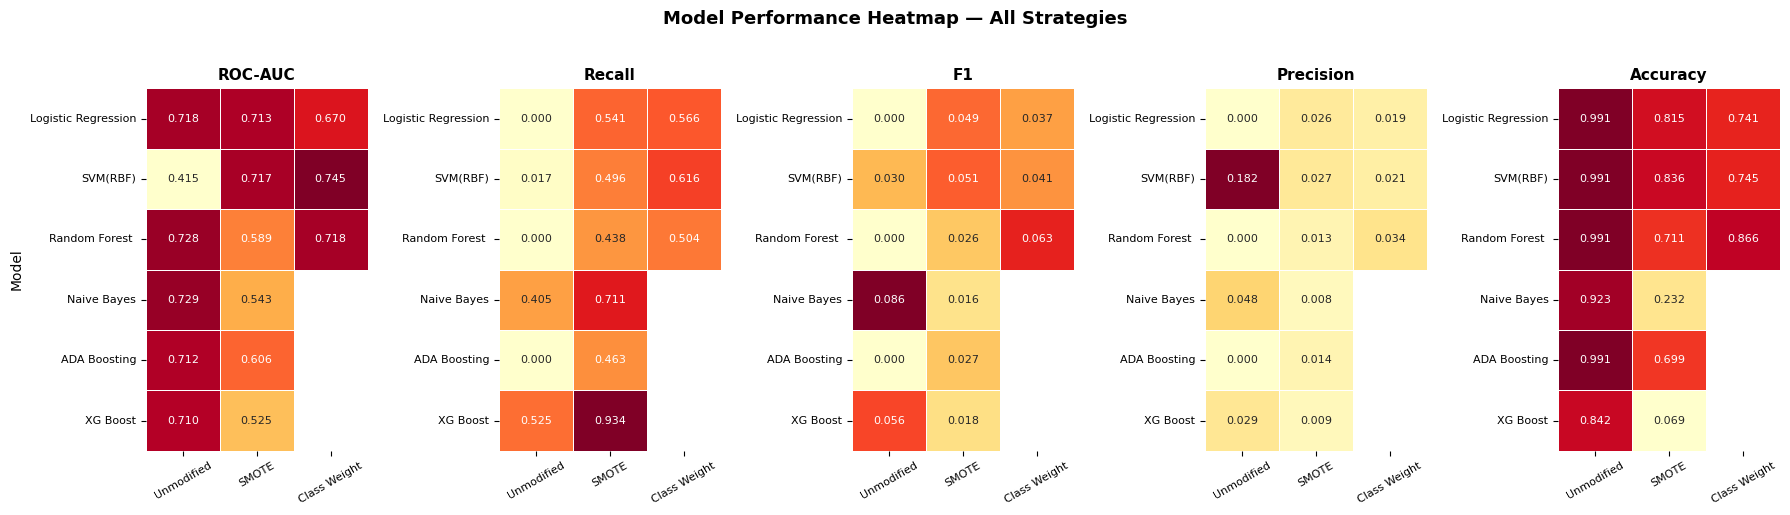

Saved: figures/results_heatmap.png


In [137]:

# ── Metrics to show in the heatmap ───────────────────────────────────────
metrics = ["ROC-AUC", "Recall", "F1", "Precision", "Accuracy"]

# ── Pivot each metric into a (Model × Strategy) matrix ───────────────────
fig, axes = plt.subplots(1, len(metrics), figsize=(18, 5))

# Friendly strategy label order
strategy_order = ["none", "smote", "class_weight"]
strategy_labels = {"none": "Unmodified", "smote": "SMOTE", "class_weight": "Class Weight"}

model_order = ["Logistic Regression", "SVM(RBF)", "Random Forest ",
               "Naive Bayes", "ADA Boosting", "XG Boost"]

for ax, metric in zip(axes, metrics):
    
    pivot = (
        results_df[results_df["Strategy"].isin(strategy_order)]
        .pivot_table(index="Model", columns="Strategy", values=metric)
        .reindex(index=model_order, columns=strategy_order)
    )
    pivot.columns = [strategy_labels[s] for s in pivot.columns]

    # Per-metric colour scale so differences are visible within each panel
    vmin = pivot.min().min()
    vmax = pivot.max().max()

    sns.heatmap(
        pivot, ax=ax,
        annot=True, fmt=".3f", annot_kws={"size": 8},
        cmap="YlOrRd", vmin=vmin, vmax=vmax,
        linewidths=0.5, linecolor="white",
        cbar=False
    )
    ax.set_title(metric, fontsize=11, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("" if metric != "ROC-AUC" else "Model")
    ax.tick_params(axis="x", rotation=30, labelsize=8)
    ax.tick_params(axis="y", rotation=0,  labelsize=8)

plt.suptitle("Model Performance Heatmap — All Strategies",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("figures/results_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: figures/results_heatmap.png")